In [42]:
import sys, os
sys.path.append(os.path.abspath(".."))

sys.path.append(os.path.abspath(".."))

from spectral_detection.analysis.pipeline import pipeline 

from spectral_detection.analysis.pipeline import build_training_dataset_eigen_only, build_training_dataset_eigen_attn

import torch, json
import pandas as pd
import numpy as np

from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

## PCA

We apply `Principal Component Analysis (PCA)` to reduce the dimensionality of the feature space while retaining the most informative directions of variation in the data. PCA constructs new orthogonal features, called principal components, ordered by the amount of variance they explain. The parameter `n_components` determines how many of these directions are kept, and therefore controls the trade-off between information retention and dimensionality reduction.

Although it is tempting to choose `n_components` so as to preserve as much variance as possible, higher explained variance does not necessarily lead to better predictive performance. Some high-variance directions may reflect noise or structure that is not relevant for the classification task. For this reason, we treat `n_components` as a tuning parameter and select it based on test performance, choosing the value that gives the best empirical results rather than simply the largest retained variance.



In [ ]:
# Load the PCA pipeline first
pipe = pipeline(L=21, H=32, K=10)
pipe

pipeline(L=21, H=32, K=10, scaler=None, pca=None)

### TriviaQA data

We begin with the `TriviaQA` dataset. First, we load the data from a `.pt` file into a `Pandas` DataFrame, and then convert the `label` column to integer values. We assign `incorrect` the value `1`, since this convention is more commonly used when computing the `AUROC` score.

In [ ]:
# jsonl_pt = r"../data/spectral/temp_1/triviaqa_t1.0_n1.jsonl"
eigen_pt = r"../data/spectral/temp_1/triviaqa_Judgelabels_and_eigs_top10.pt"

payload = torch.load(eigen_pt, map_location="cpu")

# print(type(payload))
# print(payload.keys())

rows = []

for sample_id, item in payload["data"].items():

    eigvals = item["eig_top10"].numpy()

    row = {
        "id": sample_id,
        "label": item["label"],
        # "domain": item.get("domain", None),
    }

    # expand eigenvalues into columns
    for i, v in enumerate(eigvals):
        row[f"eig_{i}"] = float(v)

    rows.append(row)

df1 = pd.DataFrame(rows)

df1["label"] = df1["label"].apply(lambda x: 1 if x.lower() == "incorrect" else 0)
df1.head()

,id,label,eig_0,eig_1,eig_2,eig_3,eig_4,eig_5,eig_6,eig_7,...,eig_6710,eig_6711,eig_6712,eig_6713,eig_6714,eig_6715,eig_6716,eig_6717,eig_6718,eig_6719
0,triviaqa_00000_t1.0_ans00,1,0.353516,0.104980,0.081055,0.072754,0.053711,0.046875,0.038818,0.032227,...,0.005249,0.001221,0.000977,0.000000,-0.000557,-0.002380,-0.002502,-0.003708,-0.004761,-0.005432
1,triviaqa_00001_t1.0_ans00,1,0.261719,0.112793,0.056641,0.050781,0.027832,0.025879,0.024536,0.020752,...,0.042969,0.011902,0.001709,0.001404,0.000000,-0.000305,-0.001587,-0.002716,-0.002945,-0.003052
2,triviaqa_00002_t1.0_ans00,0,0.283203,0.201172,0.089844,0.088867,0.067871,0.065430,0.054199,0.042725,...,0.030273,0.005493,0.004761,0.000366,0.000000,-0.000664,-0.000671,-0.001297,-0.003204,-0.003265
3,triviaqa_00003_t1.0_ans00,1,0.178711,0.142578,0.044434,0.039307,0.033203,0.030518,0.029175,0.025757,...,0.012085,0.002869,0.002808,0.001495,0.000916,0.000000,-0.000366,-0.001984,-0.002289,-0.003143
4,triviaqa_00004_t1.0_ans00,1,0.127930,0.073730,0.064941,0.052002,0.038330,0.037598,0.026855,0.023438,...,0.007385,0.006104,0.005157,0.003326,0.002197,0.000000,-0.000519,-0.001190,-0.002518,-0.003113


In [17]:
eig_cols = [col for col in df1.columns if col.startswith("eig_")]
X1 = df1[eig_cols].values
y1 = df1["label"].values

# -----------------------------
# Fit PCA on the dataset
# -----------------------------
X1_pca = pipe.fit_transform(X1, pca_variance=384)
print("PCA output shape:", X1_pca.shape)
print("Num PCs kept:", pipe.pca.n_components_)
print("Explained variance retained:", pipe.pca.explained_variance_ratio_.sum())

# -----------------------------
# Put into a DataFrame for convenience
# -----------------------------
pc_cols = [f"PC{i+1}" for i in range(X1_pca.shape[1])]
df1_pca = pd.DataFrame(X1_pca, columns=pc_cols)

df1_pca["label"] = y1

df1_pca.head()

PCA output shape: (5000, 384)
Num PCs kept: 384
Explained variance retained: 0.7316729496418097


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC376,PC377,PC378,PC379,PC380,PC381,PC382,PC383,PC384,label
0,21.083353,-14.120772,-17.793718,12.725747,5.943540,-3.104733,-17.236413,3.438575,7.126851,6.058824,...,-0.704489,-0.043601,1.644806,1.252650,-0.813303,0.491614,-0.451966,0.249879,1.716768,1
1,18.069204,-8.402765,-25.374033,5.061179,11.622710,1.824561,-3.846996,13.787729,6.933621,-4.699521,...,1.309950,3.954774,5.652351,1.742480,2.037653,3.846850,0.161178,2.156318,1.339613,1
2,-28.805356,29.788096,36.715717,12.281802,-1.804486,16.762775,11.311653,8.079418,13.748440,8.856247,...,-1.897847,1.874958,1.169169,-2.604960,0.332527,-2.106537,-1.366124,0.469865,1.268694,0
3,22.362664,-6.602939,-7.995164,6.662083,16.567196,0.361286,-15.740513,2.263746,-10.191050,-4.761345,...,2.880496,2.966439,-1.559577,0.338564,-0.482872,0.188623,-0.507648,-0.165163,-1.329365,1
4,-14.360310,3.480982,23.497105,-5.537583,-3.984881,-12.366828,1.533904,5.112579,4.952311,-2.384536,...,-0.688157,-0.292294,1.057423,-0.798330,-0.595283,-1.238843,0.278741,0.865810,-2.167379,1


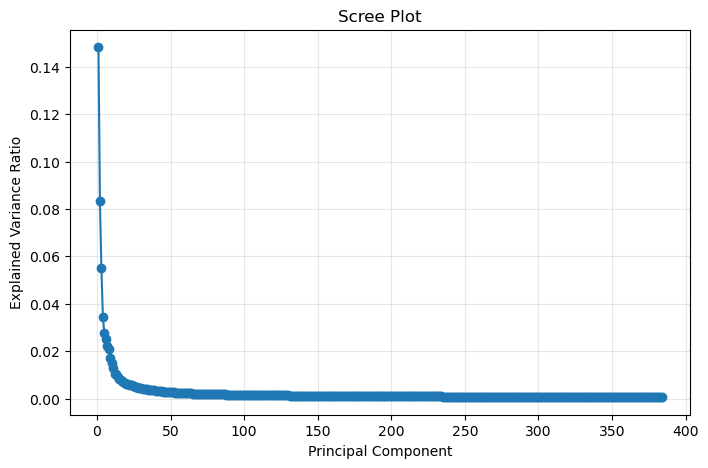

In [51]:
explained = PCA().fit(X1_pca).explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained)+1), explained, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True, alpha=0.3)
plt.show()

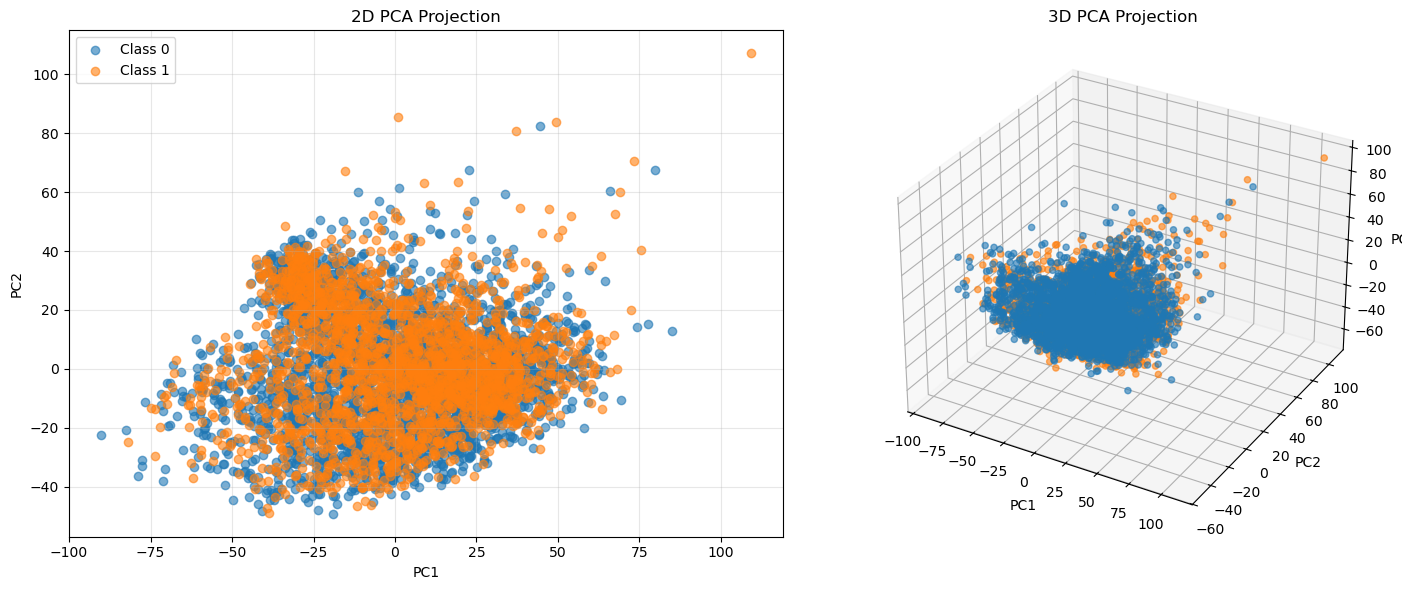

In [58]:
X1_scaled = StandardScaler().fit_transform(X1)

# Fit PCA once to 3 components
pca = PCA(n_components=3, random_state=42)
X1_pca_3d = pca.fit_transform(X1_scaled)

fig = plt.figure(figsize=(15, 6))

# 2D projection
ax1 = fig.add_subplot(1, 2, 1)
for label in np.unique(y1):
    idx = (y1 == label)
    ax1.scatter(
        X1_pca_3d[idx, 0],
        X1_pca_3d[idx, 1],
        alpha=0.6,
        label=f"Class {label}"
    )

ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_title("2D PCA Projection")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 3D projection
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
for label in np.unique(y1):
    idx = (y1 == label)
    ax2.scatter(
        X1_pca_3d[idx, 0],
        X1_pca_3d[idx, 1],
        X1_pca_3d[idx, 2],
        alpha=0.6,
        label=f"Class {label}"
    )

ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_zlabel("PC3")
ax2.set_title("3D PCA Projection")

plt.tight_layout()
plt.show()

### MMLU Data

We next repeat the same preprocessing pipeline for the `MMLU` data. Unlike the `TriviaQA`, we load the raw eigenvalues from a `.pt` file and the labels from a `.json` file into a Pandas DataFrame, convert the label column to integer values, and use this processed table as the basis for downstream analysis. We then apply `PCA` to reduce the dimensionality of the feature space while preserving the most useful variation in the data.

In [30]:
jsonl_pt = r"../data/spectral/temp_1/mmlu_t1.0_n1.jsonl"
eigen_pt = r"../data/spectral/temp_1/mmlu_t1.0_n1_eigen.pt"

df2, X2, y2 = build_training_dataset_eigen_only(jsonl_pt, eigen_pt)

# -----------------------------
# Fit PCA on the dataset
# -----------------------------
X2_pca = pipe.fit_transform(X2, pca_variance=384)
print("PCA output shape:", X2_pca.shape)
print("Num PCs kept:", pipe.pca.n_components_)
print("Explained variance retained:", pipe.pca.explained_variance_ratio_.sum())

# -----------------------------
# Put into a DataFrame for convenience
# -----------------------------
pc_cols = [f"PC{i+1}" for i in range(X2_pca.shape[1])]
df2_pca = pd.DataFrame(X2_pca, columns=pc_cols)

df2_pca["label"] = y2 

df2_pca.head()

Feature Matrix (X) shape: (5000, 6720)
Label Vector (y) shape: (5000,)
PCA output shape: (5000, 384)
Num PCs kept: 384
Explained variance retained: 0.71670556


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC376,PC377,PC378,PC379,PC380,PC381,PC382,PC383,PC384,label
0,28.095064,19.478039,4.851558,-18.490509,-6.517578,-16.811510,-7.449890,-0.066920,10.273472,-7.211315,...,-1.774464,0.956340,-0.930499,1.165496,-1.424996,-0.649247,2.663069,-3.449059,-0.982122,1
1,17.192455,4.522413,5.463420,9.894528,-8.939187,-14.678574,-7.786423,9.399705,-8.389603,8.575727,...,-1.209571,1.364111,-1.364093,0.153792,-0.357946,1.423072,0.112397,2.014021,-0.581758,1
2,25.700315,-15.575480,7.821294,1.181172,-15.325194,-12.097714,15.802476,6.666349,-6.045352,-3.426765,...,3.884359,0.421324,-0.418824,3.341633,-0.430574,-1.192797,1.788197,-2.133632,0.939947,0
3,-32.283165,29.817291,-12.415525,12.504240,-14.984830,5.352409,2.917727,13.761703,-9.107214,-3.770853,...,1.623359,0.036573,-3.336930,1.002101,2.792706,-1.448940,-0.697294,0.109856,-1.272030,0
4,8.332963,-12.712513,-7.955003,3.518071,-0.781159,5.736646,3.065596,-2.108029,7.123907,1.174107,...,0.558914,-2.455816,2.457942,1.703779,-0.049984,-0.093001,-0.299778,-1.245265,-1.392543,1


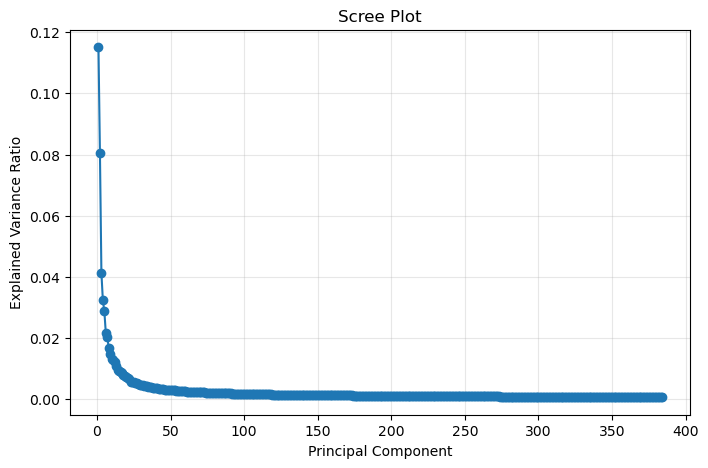

In [52]:
explained = PCA().fit(X2_pca).explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained)+1), explained, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True, alpha=0.3)
plt.show()

### Halueval Data

We repeat the same process as in `MMLU` for `Halueval` data.

In [10]:
jsonl_pt = r"../data/spectral/temp_1/halueval_t1.5_n1_1000s_prompt2.jsonl"
eigen_pt = r"../data/spectral/temp_1/halueval_t1.5_n1_eigen_1000s_prompt2.pt"

df3, X3, y3 = build_training_dataset_eigen_only(jsonl_pt, eigen_pt)

# -----------------------------
# Fit PCA on the dataset
# -----------------------------
X3_pca = pipe.fit_transform(X3, pca_variance=384)
print("PCA output shape:", X3_pca.shape)
print("Num PCs kept:", pipe.pca.n_components_)
print("Explained variance retained:", pipe.pca.explained_variance_ratio_.sum())

# -----------------------------
# Put into a DataFrame for convenience
# -----------------------------
pc_cols = [f"PC{i+1}" for i in range(X3_pca.shape[1])]
df3_pca = pd.DataFrame(X3_pca, columns=pc_cols)

df3_pca["label"] = y3

df3_pca.head()

Feature Matrix (X) shape: (10000, 6720)
Label Vector (y) shape: (10000,)
PCA output shape: (10000, 384)
Num PCs kept: 384
Explained variance retained: 0.6758161


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC376,PC377,PC378,PC379,PC380,PC381,PC382,PC383,PC384,label
0,23.745876,-4.078286,-5.536478,-9.591880,3.528214,-5.588743,9.179480,4.338947,-7.959311,-4.226789,...,-4.063235,-0.831675,-0.649879,-1.214425,-0.169978,1.643615,1.245643,-0.451849,1.139578,1
1,-8.324525,-3.370966,16.541647,2.547406,-7.275445,24.000172,5.934996,6.335611,-16.427288,1.983711,...,2.019006,1.289178,-0.905861,2.421062,2.622987,0.168721,-2.716952,-1.957221,-2.648401,0
2,-35.974014,-7.751677,-39.317371,19.958078,1.220890,-24.410349,-0.044151,9.653181,-9.045692,4.235579,...,-1.308296,0.233173,1.847799,2.956341,0.836572,0.164419,1.182812,-1.368313,-0.665999,0
3,15.101840,-7.308656,4.300933,-6.253879,1.836344,4.708498,-3.641434,9.053026,0.477283,-7.454624,...,-0.401542,-2.453494,-0.914601,-1.977260,0.183272,-2.972345,-2.289459,3.009821,1.271657,0
4,-11.150686,0.131988,16.755680,-13.999888,-8.046177,10.271710,-7.938172,6.917695,3.589702,5.085608,...,-0.107575,-0.743251,-0.776013,-4.911647,-0.534315,-0.874865,1.021189,0.945209,1.914675,1


### nq_Open Data

In [9]:
jsonl_pt = r"../data/spectral/temp_1/nq_open_t1.0_n1_3600s.jsonl"
eigen_pt = r"../data/spectral/temp_1/nq_open_t1.0_n1_eigen_3600s.pt"

df4, X4, y4 = build_training_dataset_eigen_only(jsonl_pt, eigen_pt)

# -----------------------------
# Fit PCA on the dataset
# -----------------------------
pca_variance = 128
X4_pca = pipe.fit_transform(X4, pca_variance)
print("PCA output shape:", X4_pca.shape)
print("Num PCs kept:", pipe.pca.n_components_)
print("Explained variance retained:", pipe.pca.explained_variance_ratio_.sum())

# -----------------------------
# Put into a DataFrame for convenience
# -----------------------------
pc_cols = [f"PC{i+1}" for i in range(X4_pca.shape[1])]
df4_pca = pd.DataFrame(X4_pca, columns=pc_cols)

df4_pca["label"] = y4

df4_pca.head()

Feature Matrix (X) shape: (3600, 6720)
Label Vector (y) shape: (3600,)
PCA output shape: (3600, 128)
Num PCs kept: 128
Explained variance retained: 0.58681035


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC120,PC121,PC122,PC123,PC124,PC125,PC126,PC127,PC128,label
0,-28.606581,-10.033376,-0.936387,20.720356,-10.276947,-2.740998,3.564226,-4.955489,-0.203204,6.748596,...,-2.359747,1.452345,-4.030432,-1.855793,-3.506316,-1.511023,-0.860575,1.442400,1.525830,0
1,6.530849,8.132248,-22.158241,-16.959621,-7.863954,-6.322883,-16.405167,-1.852580,7.896450,4.429074,...,0.671664,0.036747,-1.100366,0.175892,-2.349734,-1.091094,-1.250134,0.022431,-0.213464,1
2,-13.539387,-12.022528,-11.374070,7.810361,0.082707,-8.850751,1.351131,-9.890806,13.091533,-9.432091,...,2.468489,2.008131,-2.765087,2.455222,-1.069483,0.410809,0.023615,-1.462117,-1.070939,1
3,-14.507421,1.560381,3.363987,-1.508633,13.914679,-13.189363,-6.720227,-6.447365,-1.174407,-5.769117,...,-1.640160,-1.012167,-4.034598,0.033259,0.487744,3.300834,2.073650,1.755714,2.724403,1
4,-1.169931,11.841812,11.852479,-8.863475,-9.387592,-14.981666,-16.684780,2.827376,2.943505,6.609279,...,-0.239871,-1.179882,-3.101745,1.104820,0.829441,1.735478,-0.691899,-0.315470,-0.980106,1


### TriviaQA + MMLU 

We then combine the `MMLU` and `TriviaQA` datasets and perform PCA on the merged feature set before training, in order to examine how well representations from different datasets work together in a shared training pipeline. This allows us to test whether combining data sources improves performance and to assess how effectively a model trained on the joint dataset generalizes across the mixed distribution.

In [11]:
X12 = np.vstack([X1, X2])
y12 = np.hstack([y1, y2])

X12.shape, y12.shape

# -----------------------------
# Fit PCA on the dataset
# -----------------------------
X12_pca = pipe.fit_transform(X12, pca_variance=384)
print("PCA output shape:", X12_pca.shape)
print("Num PCs kept:", pipe.pca.n_components_)
print("Explained variance retained:", pipe.pca.explained_variance_ratio_.sum())

# -----------------------------
# Put into a DataFrame for convenience
# -----------------------------
pc_cols = [f"PC{i+1}" for i in range(X12_pca.shape[1])]
df12_pca = pd.DataFrame(X12_pca, columns=pc_cols)

df12_pca["label"] = y12

df12_pca.head()

PCA output shape: (10000, 384)
Num PCs kept: 384
Explained variance retained: 0.7133093690779598


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC376,PC377,PC378,PC379,PC380,PC381,PC382,PC383,PC384,label
0,-1.094865,27.862167,-26.793908,12.981636,9.381119,6.708258,-1.340294,-5.389115,-6.179338,13.179383,...,-3.024794,-1.466401,3.049803,3.420770,1.297236,1.120805,-0.109019,-1.768722,-1.099823,1
1,-2.032936,14.817370,-23.542576,16.847013,14.676365,-1.994764,6.884055,-6.623255,-10.491322,-4.347425,...,-1.823741,2.405826,-0.471973,-0.808173,0.375628,2.262290,-2.013082,2.855024,-1.887634,1
2,39.350086,10.462175,47.182297,-3.746812,0.416630,3.043195,2.298111,13.113747,-4.731201,3.543718,...,0.792633,-0.174637,-2.335595,0.565340,0.237504,1.038216,0.704883,0.743709,-2.163200,0
3,-5.219615,24.006729,-16.933551,8.035086,-2.114434,8.607027,7.773032,-5.978483,-8.853668,-0.382581,...,1.400813,1.970947,0.279494,0.167970,-1.492949,1.992282,-0.705905,-0.413101,-1.709668,1
4,31.986464,16.919031,12.676443,-7.486537,-5.267607,-6.135123,-12.971660,1.598459,4.758632,-8.732115,...,-0.303394,1.194282,-1.870193,-0.781810,-1.497431,0.269865,2.052996,-3.348043,-2.955753,1


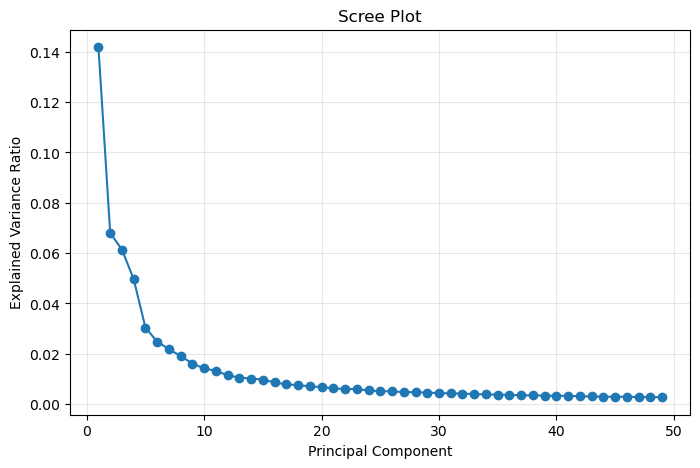

In [60]:
explained = PCA().fit(X12_pca).explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(8,5))
plt.plot(range(1, 50), explained[:49], marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True, alpha=0.3)
plt.show()

The plot of the cumulative variance for first 50 Principal components show that the majority of the variance is retained by the first few principal components.

## Training

After preprocessing, we train a binary classifier on the resulting features to distinguish between the two label classes. Since the goal is predictive performance rather than adherence to a single model family, we test several standard classifiers and compare their behavior on the same train–test split. This allows us to assess which methods are best suited to the structure of the data.

For each classifier, we also perform hyperparameter tuning to optimize its performance. The choice of hyperparameters can significantly affect accuracy, AUROC, and generalization, so they are treated as part of the model-selection process rather than fixed in advance. By comparing multiple classifiers under tuned settings, we identify the model that gives the strongest test results for the binary classification task.

### TriviaQA

In [18]:
classes = df1_pca["label"].unique()
print("Unique classes in the dataset:", classes)

# df_pca_labeled should have columns: PC1..PCn and a label column with: 0 for correct and 1 for incorrect

df_train = df1_pca.copy()

# -------------------------
# Build X (PC columns) and y (2-class labels)
# -------------------------
pc_cols = [c for c in df_train.columns if c.startswith("PC")]
X_triv = df_train[pc_cols].to_numpy()
y_triv = df_train["label"].to_numpy()

print("X shape:", X_triv.shape)
print("y distribution:\n", pd.Series(y_triv).value_counts())

Unique classes in the dataset: [1 0]
X shape: (5000, 384)
y distribution:
 0    2844
1    2156
Name: count, dtype: int64


In [ ]:
# -------------------------
# Train/test split (stratified)
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_triv, y_triv,
    test_size=0.2,
    random_state=33,
    stratify=y_triv
)

# -------------------------
# Multi-class classifier (Logistic regression supports multinomial)
# -------------------------
log_clf = Pipeline([
    ("scaler", StandardScaler()),  # PCs are already scaled-ish, but this is safe
    ("lr", LogisticRegression(
        penalty="l2",
        max_iter=5000,
        C=0.001,        
        class_weight="balanced"
    ))
])

log_clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(C=0.001, class_weight='balanced',
                                    max_iter=5000))])


Classification report:
              precision    recall  f1-score   support

           0      0.673     0.645     0.659       569
           1      0.556     0.587     0.571       431

    accuracy                          0.620      1000
   macro avg      0.615     0.616     0.615      1000
weighted avg      0.623     0.620     0.621      1000


Confusion matrix (rows=true, cols=pred):
        pred_1  pred_0
true_1     253     178
true_0     202     367
AUROC (incorrect as positive): 0.6376188126684581


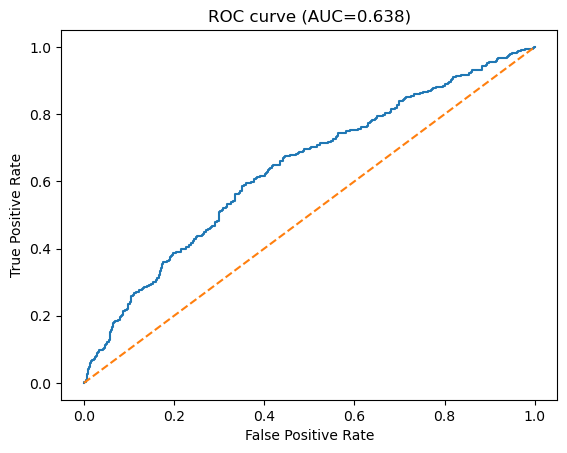

In [20]:
# -------------------------
# Evaluate
# -------------------------
y_pred = log_clf.predict(X_test)

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

print("\nConfusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(confusion_matrix(y_test, y_pred, labels=classes),
                   index=[f"true_{c}" for c in classes],
                   columns=[f"pred_{c}" for c in classes]))

# probability score for the positive class ("incorrect")
pos_idx = list(log_clf.classes_).index(1)   # important: don't assume column order
y_score = log_clf.predict_proba(X_test)[:, pos_idx]

# AUROC
auc = roc_auc_score(y_test, y_score)
print("AUROC (incorrect as positive):", auc)

# plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve (AUC={auc:.3f})")
plt.show()

### MMLU Training

In [31]:
classes = df2_pca["label"].unique()
print("Unique classes in the dataset:", classes)

df_train = df2_pca.copy()

# -------------------------
# Build X (PC columns) and y (2-class labels)
# -------------------------
pc_cols = [c for c in df_train.columns if c.startswith("PC")]
X_mmlu = df_train[pc_cols].to_numpy()
y_mmlu = df_train["label"].to_numpy()

print("X shape:", X_mmlu.shape)
print("y distribution:\n", pd.Series(y_mmlu).value_counts())

Unique classes in the dataset: [1 0]
X shape: (5000, 384)
y distribution:
 1    3673
0    1327
Name: count, dtype: int64


In [ ]:
# -------------------------
# Train/test split (stratified)
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_mmlu, y_mmlu,
    test_size=0.2,
    random_state=33,
    stratify=y_mmlu
)

# -------------------------
# Multi-class classifier
#    (Logistic regression supports multinomial)
# -------------------------
log_clf = Pipeline([
    ("scaler", StandardScaler()),  # PCs are already scaled-ish, but this is safe
    ("lr", LogisticRegression(
        penalty="l2",
        max_iter=5000,
        C=0.001,        
        class_weight="balanced",   # helps if classes are imbalanced
    ))
])

log_clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(C=0.001, class_weight='balanced',
                                    max_iter=5000))])


Classification report:
              precision    recall  f1-score   support

           0      0.426     0.634     0.510       265
           1      0.840     0.693     0.759       735

    accuracy                          0.677      1000
   macro avg      0.633     0.663     0.634      1000
weighted avg      0.730     0.677     0.693      1000


Confusion matrix (rows=true, cols=pred):
        pred_1  pred_0
true_1     509     226
true_0      97     168
AUROC (incorrect as positive): 0.7158208188935952


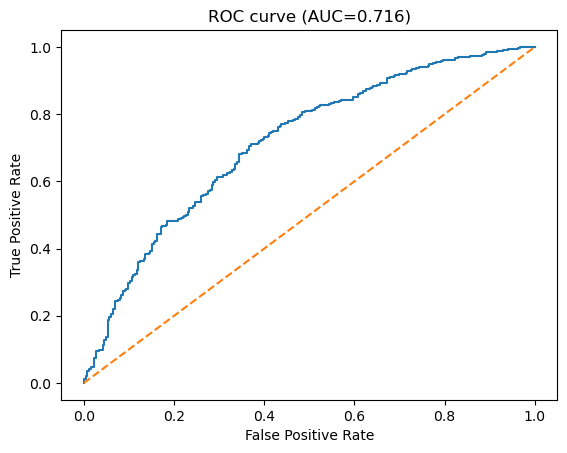

In [37]:
# -------------------------
# Evaluate
# -------------------------
y_pred = log_clf.predict(X_test)

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

print("\nConfusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(confusion_matrix(y_test, y_pred, labels=classes),
                   index=[f"true_{c}" for c in classes],
                   columns=[f"pred_{c}" for c in classes]))

# probability score for the positive class ("incorrect")
pos_idx = list(log_clf.classes_).index(1)   # important: don't assume column order
y_score = log_clf.predict_proba(X_test)[:, pos_idx]

# AUROC
auc = roc_auc_score(y_test, y_score)
print("AUROC (incorrect as positive):", auc)

# Optional: plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve (AUC={auc:.3f})")
plt.show()

### Halueval Training

In [40]:
classes = df3_pca["label"].unique()
print("Unique classes in the dataset:", classes)

df_train = df3_pca.copy()

# -------------------------
# Build X (PC columns) and y (2-class labels)
# -------------------------
pc_cols = [c for c in df_train.columns if c.startswith("PC")]
X_hal = df_train[pc_cols].to_numpy()
y_hal = df_train["label"].to_numpy()

print("X shape:", X_hal.shape)
print("y distribution:\n", pd.Series(y_hal).value_counts())

# -------------------------
# Train/test split (stratified)
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_hal, y_hal,
    test_size=0.2,
    random_state=137,
    stratify=y_hal
)

# -------------------------
# Binary-class classifier (Logistic regression)
# -------------------------
log_clf = Pipeline([
    ("scaler", StandardScaler()),  # PCs are already scaled-ish, but this is safe
    ("lr", LogisticRegression(
        # penalty="l2",
        max_iter=2000,
        # C=0.001,        
        class_weight="balanced",   
    ))
])

log_clf.fit(X_train, y_train)

Unique classes in the dataset: [1 0]
X shape: (10000, 384)
y distribution:
 0    6818
1    3182
Name: count, dtype: int64


Pipeline(steps=[('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])


Classification report:
              precision    recall  f1-score   support

           0      0.757     0.630     0.688      1364
           1      0.417     0.568     0.481       636

    accuracy                          0.610      2000
   macro avg      0.587     0.599     0.584      2000
weighted avg      0.649     0.610     0.622      2000


Confusion matrix (rows=true, cols=pred):
        pred_1  pred_0
true_1     361     275
true_0     505     859
AUROC (incorrect as positive): 0.6414287426916764


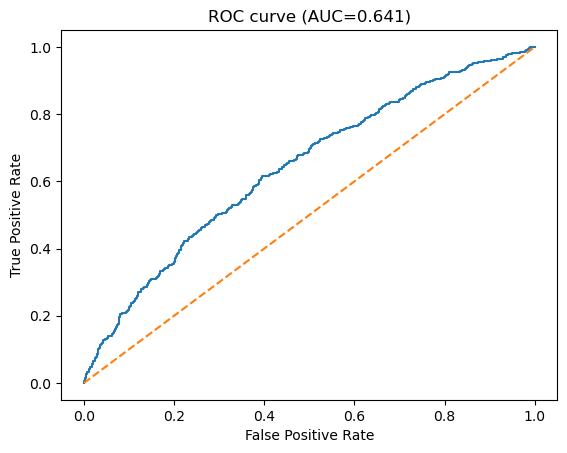

In [41]:
# -------------------------
# Evaluate
# -------------------------
y_pred = log_clf.predict(X_test)

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

print("\nConfusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(confusion_matrix(y_test, y_pred, labels=classes),
                   index=[f"true_{c}" for c in classes],
                   columns=[f"pred_{c}" for c in classes]))

# probability score for the positive class ("incorrect")
pos_idx = list(log_clf.classes_).index(1)   # important: don't assume column order
y_score = log_clf.predict_proba(X_test)[:, pos_idx]

# AUROC
auc = roc_auc_score(y_test, y_score)
print("AUROC (incorrect as positive):", auc)

# Optional: plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve (AUC={auc:.3f})")
plt.show()

### nq_Open Training

In [38]:
classes = df4_pca["label"].unique()
print("Unique classes in the dataset:", classes)

df_train = df4_pca.copy()

# -------------------------
# Build X (PC columns) and y (2-class labels)
# -------------------------
pc_cols = [c for c in df_train.columns if c.startswith("PC")]
X_nq = df_train[pc_cols].to_numpy()
y_nq = df_train["label"].to_numpy()

print("X shape:", X_nq.shape)
print("y distribution:\n", pd.Series(y_nq).value_counts())

# -------------------------
# Train/test split (stratified)
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_nq, y_nq,
    test_size=0.2,
    random_state=33,
    stratify=y_nq
)

# -------------------------
# Multi-class classifier (Logistic regression supports multinomial)
# -------------------------
log_clf = Pipeline([
    ("scaler", StandardScaler()),  # PCs are already scaled-ish, but this is safe
    ("lr", LogisticRegression(
        penalty="l2",
        max_iter=5000,
        C=0.001,        
        class_weight="balanced",   # helps if classes are imbalanced
    ))
])

log_clf.fit(X_train, y_train)

Unique classes in the dataset: [0 1]
X shape: (3600, 128)
y distribution:
 1    2565
0    1035
Name: count, dtype: int64


Pipeline(steps=[('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(C=0.001, class_weight='balanced',
                                    max_iter=5000))])


Classification report:
              precision    recall  f1-score   support

           0      0.359     0.570     0.440       207
           1      0.772     0.589     0.668       513

    accuracy                          0.583       720
   macro avg      0.566     0.579     0.554       720
weighted avg      0.653     0.583     0.603       720


Confusion matrix (rows=true, cols=pred):
        pred_0  pred_1
true_0     118      89
true_1     211     302
AUROC (incorrect as positive): 0.6119256810840843


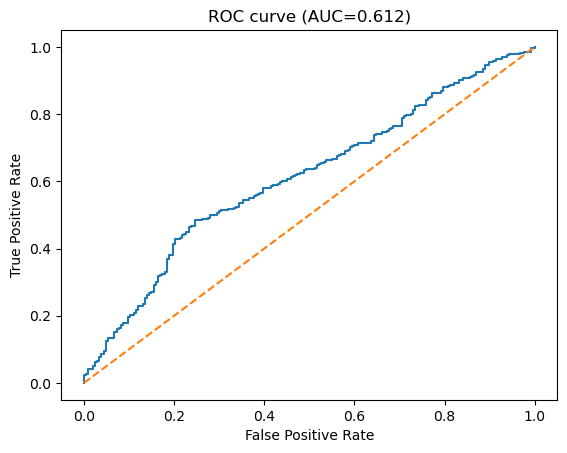

In [39]:
# -------------------------
# Evaluate
# -------------------------
y_pred = log_clf.predict(X_test)

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

print("\nConfusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(confusion_matrix(y_test, y_pred, labels=classes),
                   index=[f"true_{c}" for c in classes],
                   columns=[f"pred_{c}" for c in classes]))

# probability score for the positive class ("incorrect")
pos_idx = list(log_clf.classes_).index(1)   # important: don't assume column order
y_score = log_clf.predict_proba(X_test)[:, pos_idx]

# AUROC
auc = roc_auc_score(y_test, y_score)
print("AUROC (incorrect as positive):", auc)

# Optional: plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve (AUC={auc:.3f})")
plt.show()

## Triviaqa + MMLU

In [ ]:
df_pca_TM = pd.read_csv(r"../data/spectral/temp_1/triviaqa_mmlu_pca.csv")
# df_pca_mmlu = pd.read_csv(r"../data/spectral/temp_1/mmlu_pca.csv")

classes = df_pca_TM["label"].unique()
print("Unique classes in the dataset:", classes)

# df_pca_labeled should have columns: PC1..PCn and a label column with:

LABEL_COL = "label"  # <-- change if your column name is different


df_train = df_pca_TM.copy()

# -------------------------
# Build X (PC columns) and y (2-class labels)
# -------------------------
pc_cols = [c for c in df_train.columns if c.startswith("PC")]
X = df_train[pc_cols].to_numpy()
y = df_train[LABEL_COL].to_numpy()

print("X shape:", X.shape)
print("y distribution:\n", pd.Series(y).value_counts())

         PC1        PC2        PC3        PC4        PC5       PC6        PC7  \
0  -1.094865  27.862167 -26.793908  12.981636   9.381119  6.708258  -1.340294   
1  -2.032936  14.817370 -23.542576  16.847013  14.676365 -1.994764   6.884055   
2  39.350086  10.462175  47.182297  -3.746812   0.416630  3.043195   2.298111   
3  -5.219615  24.006729 -16.933551   8.035086  -2.114434  8.607027   7.773032   
4  31.986464  16.919031  12.676443  -7.486537  -5.267607 -6.135123 -12.971660   

         PC8        PC9       PC10  ...     PC376     PC377     PC378  \
0  -5.389115  -6.179338  13.179383  ...  1.141642 -1.513671 -0.356864   
1  -6.623255 -10.491322  -4.347425  ...  0.640012  1.805900 -0.805777   
2  13.113747  -4.731201   3.543718  ...  1.910907 -0.814500 -0.884993   
3  -5.978483  -8.853668  -0.382581  ... -0.982953  3.229909  1.547978   
4   1.598459   4.758632  -8.732115  ... -0.810313  0.893578 -3.911738   

      PC379     PC380     PC381     PC382     PC383     PC384  label  
0 -

In [ ]:
# -------------------------
# Train/test split (stratified)
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------
# Binary-class classifier (Logistic regression)
# -------------------------
log_clf = Pipeline([
    ("scaler", StandardScaler()),  # PCs are already scaled-ish, but this is safe
    ("lr", LogisticRegression(
        penalty="l2",
        max_iter=5000,
        C=0.001,        
        class_weight="balanced",   # helps if classes are imbalanced
        # multi_class="multinomial",
        # solver="saga",
        # l1_ratio=0.8,              # elastic net mixing
    ))
])

log_clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(C=0.001, class_weight='balanced',
                                    max_iter=5000))])

In [ ]:
# -------------------------
# Evaluate
# -------------------------
y_pred = log_clf.predict(X_test)

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

print("\nConfusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(confusion_matrix(y_test, y_pred, labels=classes),
                   index=[f"true_{c}" for c in classes],
                   columns=[f"pred_{c}" for c in classes]))


Classification report:
              precision    recall  f1-score   support

           0      0.752     0.684     0.716      1166
           1      0.607     0.685     0.644       834

    accuracy                          0.684      2000
   macro avg      0.680     0.684     0.680      2000
weighted avg      0.692     0.684     0.686      2000


Confusion matrix (rows=true, cols=pred):
        pred_0  pred_1
true_0     797     369
true_1     263     571


AUROC (incorrect as positive): 0.7516206588759867


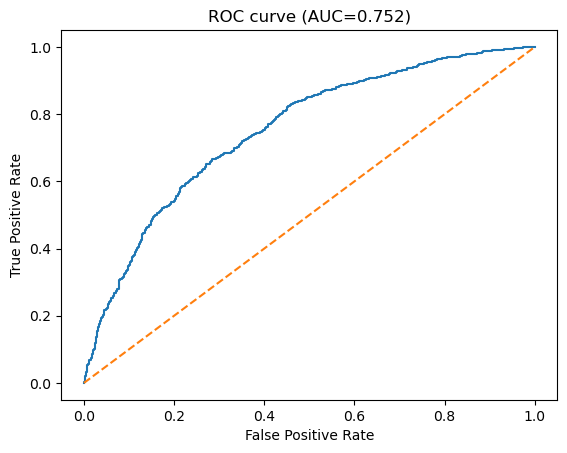

In [5]:
# y_true = (np.array(y_test) == "incorrect").astype(int)

# probability score for the positive class ("incorrect")
pos_idx = list(log_clf.classes_).index(1)   # important: don't assume column order
y_score = log_clf.predict_proba(X_test)[:, pos_idx]

# AUROC
auc = roc_auc_score(y_test, y_score)
print("AUROC (incorrect as positive):", auc)

# Optional: plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve (AUC={auc:.3f})")
plt.show()

## Try Different Classifiers to Compare on the TriviaQA + MMLU dataset

To assess how robust the signal is on the combined TriviaQA + MMLU dataset, we compare several standard classifiers with different inductive biases. In particular, we evaluate Logistic Regression, Random Forest, SVM, AdaBoost, and SGDClassifier with both hinge and log-loss objectives. This gives a useful spread across linear, kernel-based, ensemble, and large-scale optimization methods.

The goal is not only to identify the best-performing classifier, but also to understand whether the predictive signal is primarily linear or whether it benefits from nonlinear decision boundaries and ensemble effects. Logistic Regression and SGD with log-loss serve as strong linear baselines, SVM tests margin-based separation, while Random Forest and AdaBoost probe whether tree-based nonlinear structure improves performance.

We compare these models using the same train/test split and feature pipeline so that differences in performance reflect the classifier choice rather than preprocessing differences. Metrics such as accuracy and AUROC can then be used to determine which model is most effective for hallucination detection on the merged TriviaQA + MMLU setting.

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [44]:
X = np.vstack([X1, X2])
y = np.hstack([y1, y2])

X.shape, y.shape

((10000, 6720), (10000,))

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
## Logistic regression with PCA

pipe1 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=384, random_state=42)),
    ("lr", LogisticRegression(penalty="l2", max_iter=5000, class_weight="balanced"))
])

pipe1.fit(X_train, y_train)

y_pred = pipe1.predict(X_test)
y_score = pipe1.predict_proba(X_test)[:, 1]   # prob of class 1

acc = accuracy_score(y_test, y_pred)
auroc = roc_auc_score(y_test, y_score)


results_df = pd.DataFrame({
    "Model": ["Logistic Regression + PCA"],
    "PCA Components": [384],
    "Test Accuracy": [acc],
    "Test AUROC": [auroc],
})

results_df

,Model,PCA Components,Test Accuracy,Test AUROC
0,Logistic Regression + PCA,384,0.6745,0.741799


In [55]:
import warnings
warnings.filterwarnings("ignore")

In [49]:
## Linear SVM + calibration

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

base = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=768, random_state=42)),
    ("svc", LinearSVC(C=1.0, max_iter=20000))   # increase iterations for SVC too
])

cal = CalibratedClassifierCV(
    estimator=base,
    method="sigmoid",   # simpler than isotonic, often enough
    cv=3                # lower cv reduces calibration fits
)

cal.fit(X_train, y_train)

y_pred = cal.predict(X_test)
y_score = cal.predict_proba(X_test)[:, 1]   # prob of class 1

acc = accuracy_score(y_test, y_pred)
auroc = roc_auc_score(y_test, y_score)


results_df = pd.DataFrame({
    "Model": ["Linear SVM + Calibration"],
    "PCA Components": [768],
    "Test Accuracy": [acc],
    "Test AUROC": [auroc],
})

results_df

,Model,PCA Components,Test Accuracy,Test AUROC
0,Linear SVM + Calibration,768,0.6805,0.732166


In [61]:
## SGDClassifier (hinge or log loss) with elastic net

from sklearn.linear_model import SGDClassifier

pipe3 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=256, random_state=42)),
    ("clf", SGDClassifier(
        loss= "log_loss",   # or "log_loss" 
        penalty="elasticnet",
        alpha=1e-3,
        l1_ratio=0.25,
        max_iter=5000,
        random_state=42
    ))
])

pipe3.fit(X_train, y_train)

y_pred = pipe3.predict(X_test)
y_score = pipe3.predict_proba(X_test)[:, 1]   # prob of class 1

acc = accuracy_score(y_test, y_pred)
auroc = roc_auc_score(y_test, y_score)


results_df = pd.DataFrame({
    "Model": ["SGDClassifier with elastic net"],
    "PCA Components": [256],
    "Test Accuracy": [acc],
    "Test AUROC": [auroc],
})

results_df

,Model,PCA Components,Test Accuracy,Test AUROC
0,SGDClassifier with elastic net,256,0.634,0.675169


In [64]:
## RandomForest / ExtraTrees with PCA

from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier

pipe4 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=384, random_state=0)),
    ("clf", RandomForestClassifier(
    n_estimators=600, max_features="sqrt",
    min_samples_leaf=2, n_jobs=-1, random_state=137
))
])

pipe4.fit(X_train, y_train)

y_pred = pipe4.predict(X_test)
y_score = pipe4.predict_proba(X_test)[:, 1]   # prob of class 1

acc = accuracy_score(y_test, y_pred)
auroc = roc_auc_score(y_test, y_score)


results_df = pd.DataFrame({
    "Model": ["RandomForest / ExtraTrees"],
    "PCA Components": [384],
    "Test Accuracy": [acc],
    "Test AUROC": [auroc],
})

results_df

,Model,PCA Components,Test Accuracy,Test AUROC
0,RandomForest / ExtraTrees,384,0.6395,0.710276


In [63]:
## Classic AdaBoost (stumps) 

from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier


# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=137)

ada_stump = Pipeline([
    ("pca", PCA(n_components=512, random_state=0)),   # remove this line to test without PCA
    ("clf", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=137),
        n_estimators=300,
        learning_rate=0.05,
        random_state=137
    ))
])


ada_stump.fit(X_train, y_train)


y_pred = ada_stump.predict(X_test)
y_score = ada_stump.predict_proba(X_test)[:, 1]   # prob of class 1


acc = accuracy_score(y_test, y_pred)
auroc = roc_auc_score(y_test, y_score)

results_df = pd.DataFrame({
    "Model": ["AdaBoost (stumps)"],
    "PCA Components": [512],
    "Test Accuracy": [acc],
    "Test AUROC": [auroc],
})

results_df

,Model,PCA Components,Test Accuracy,Test AUROC
0,AdaBoost (stumps),512,0.6395,0.710276


In [65]:
## AdaBoost with small trees

ada_tree = Pipeline([
    ("pca", PCA(n_components=512, random_state=0)),  # try removing PCA too
    ("clf", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2, min_samples_leaf=2, random_state=137),
        n_estimators=400,
        learning_rate=0.05,
        random_state=137
    ))
])

ada_tree.fit(X_train, y_train)

y_pred = ada_stump.predict(X_test)
y_score = ada_stump.predict_proba(X_test)[:, 1]   # prob of class 1

acc = accuracy_score(y_test, y_pred)
auroc = roc_auc_score(y_test, y_score)


results_df = pd.DataFrame({
    "Model": ["AdaBoost with small trees"],
    "PCA Components": [512],
    "Test Accuracy": [acc],
    "Test AUROC": [auroc],
})

results_df
# auc_scores = cross_val_score(ada_tree, X, y, scoring="roc_auc", cv=cv, n_jobs=-1)
# print("AdaBoost(tree) AUROC mean±std:", auc_scores.mean(), auc_scores.std())

,Model,PCA Components,Test Accuracy,Test AUROC
0,AdaBoost with small trees,512,0.637,0.69002


## Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=384, random_state=42)),
    ("lr", LogisticRegression(
        solver="saga",
        max_iter=5000,
        class_weight=None,   # we'll tune this
        n_jobs=-1
    ))
])

param_grid = {
    "pca__n_components": [256, 384, 512],
    "pca__whiten": [False, True],
    "lr__penalty": ["l2", "elasticnet"],
    "lr__C": [1e-2, 3e-2, 1e-1],
    "lr__l1_ratio": [0.1, 0.3, 0.5],   # only used for elasticnet; ignored for l2 by GridSearchCV? (sklearn will error)
    "lr__class_weight": [None, "balanced"],
}

# Fix: split the grid so l1_ratio only applies to elasticnet
# param_grid = [
#     {
#         "pca__n_components": [256, 384, 512, 768],
#         "pca__whiten": [False, True],
#         "lr__penalty": ["l2"],
#         "lr__C": [1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1],
#         "lr__class_weight": [None, "balanced"],
#     },
#     {
#         "pca__n_components": [256, 384, 512, 768],
#         "pca__whiten": [False, True],
#         "lr__penalty": ["elasticnet"],
#         "lr__C": [1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1],
#         "lr__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
#         "lr__class_weight": [None, "balanced"],
#     }
# ]

cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

gs = GridSearchCV(
    pipe,
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

gs.fit(X, y)  # y can be strings: 'correct'/'incorrect'
print("Best CV AUROC:", gs.best_score_)
print("Best params:", gs.best_params_)
best_model = gs.best_estimator_

Fitting 2 folds for each of 216 candidates, totalling 432 fits
Best CV AUROC: 0.7287355922607069
Best params: {'lr__C': 0.01, 'lr__class_weight': None, 'lr__l1_ratio': 0.5, 'lr__penalty': 'elasticnet', 'pca__n_components': 256, 'pca__whiten': False}
